
Processing sample: SSN092

Processing sample: SSN093

Processing sample: SSN094

Processing sample: SSN139

Processing sample: SSN140

Processing sample: SSN141

Processing sample: SSN142
    sample                                         file  field_mT  current_mA  \
0   SSN092  PHE_field_197.256deg_I_in_3.000mAtrace1.txt   197.256         3.0   
1   SSN092  PHE_field_197.562deg_I_in_9.000mAtrace1.txt   197.562         9.0   
2   SSN092  PHE_field_197.634deg_I_in_6.000mAtrace1.txt   197.634         6.0   
3   SSN093  PHE_field_197.313deg_I_in_3.000mAtrace1.txt   197.313         3.0   
4   SSN093  PHE_field_197.564deg_I_in_9.000mAtrace1.txt   197.564         9.0   
5   SSN093  PHE_field_197.628deg_I_in_6.000mAtrace1.txt   197.628         6.0   
6   SSN094  PHE_field_197.283deg_I_in_3.000mAtrace1.txt   197.283         3.0   
7   SSN094  PHE_field_197.531deg_I_in_6.000mAtrace1.txt   197.531         6.0   
8   SSN094  PHE_field_197.615deg_I_in_9.000mAtrace1.txt   197.615         9.0   
9

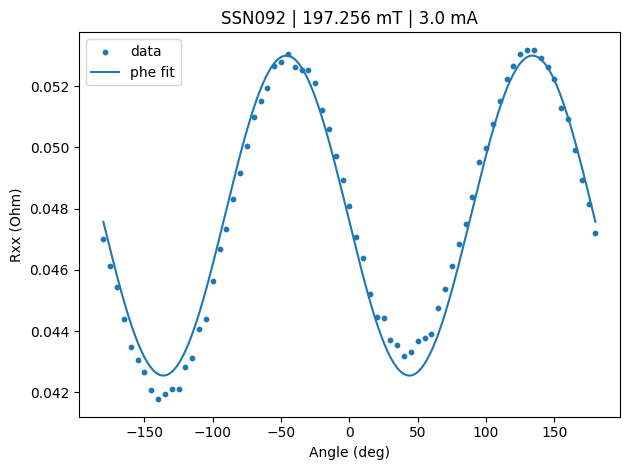

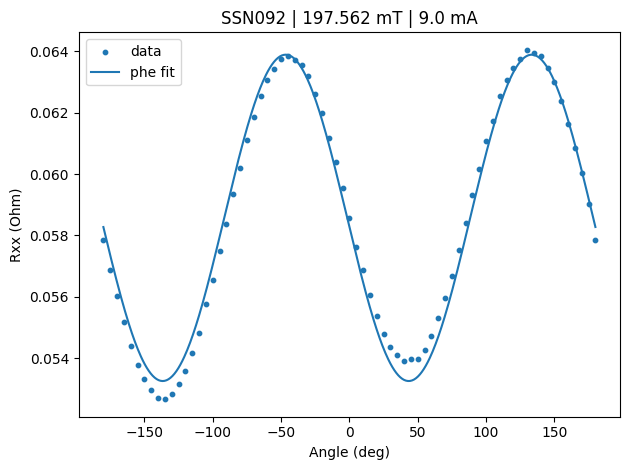

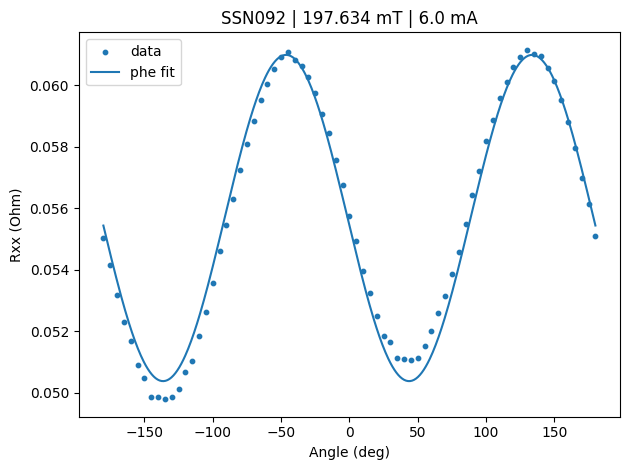

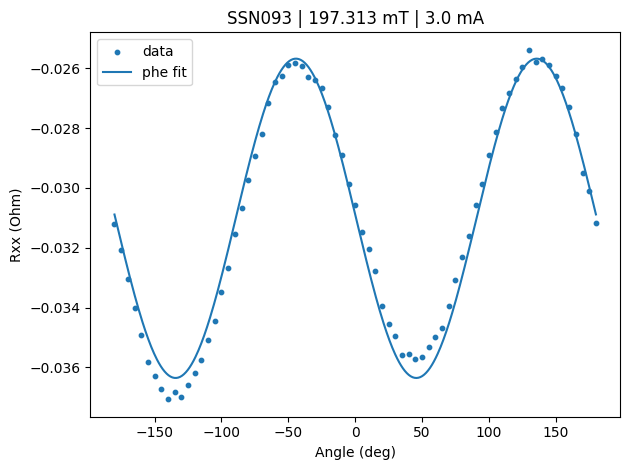

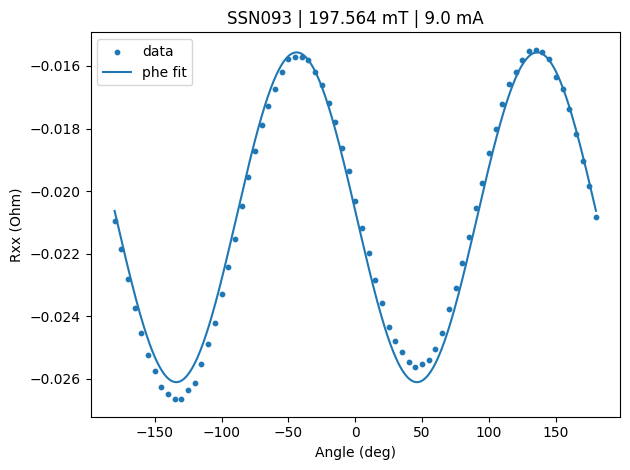

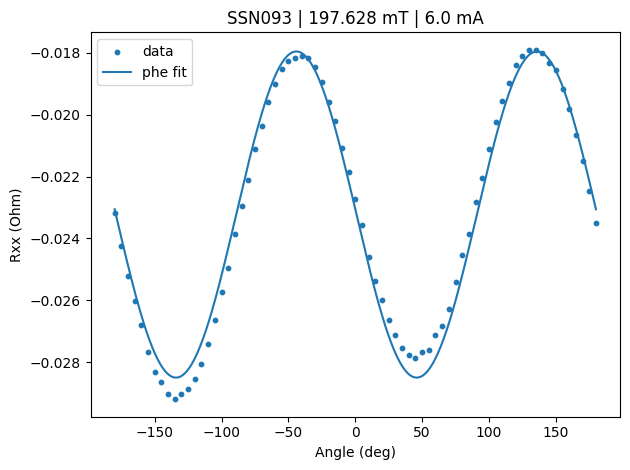

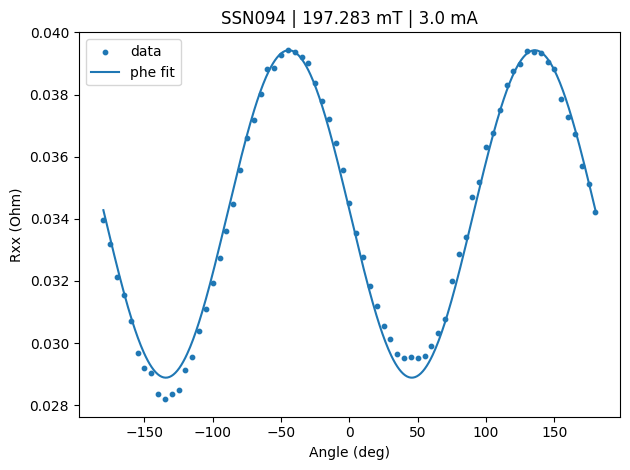

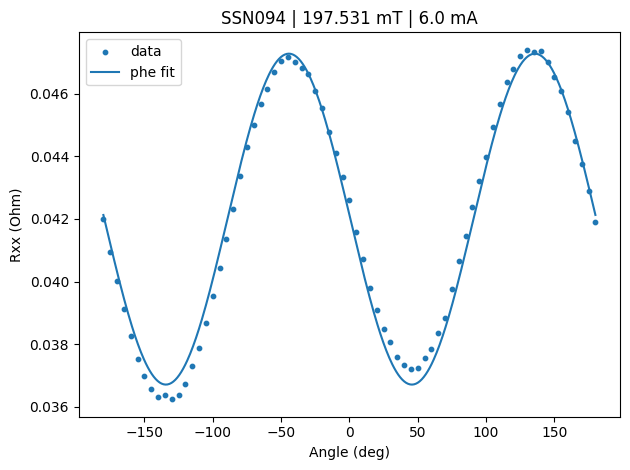

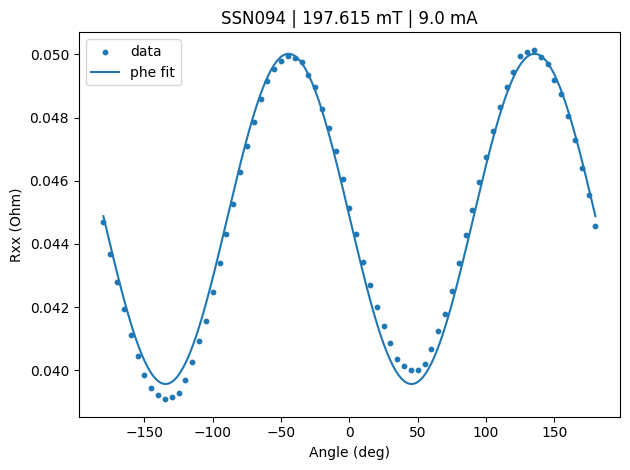

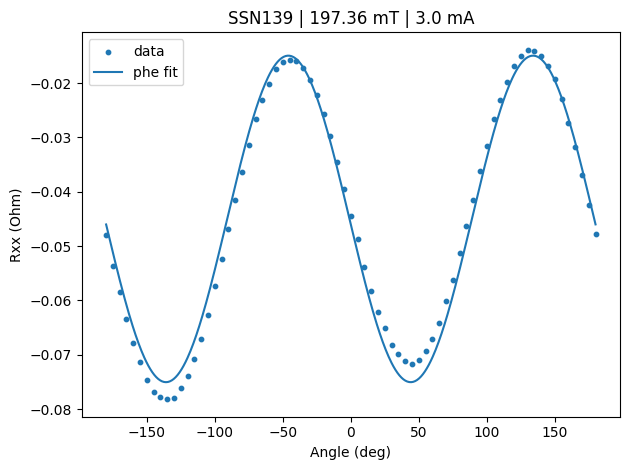

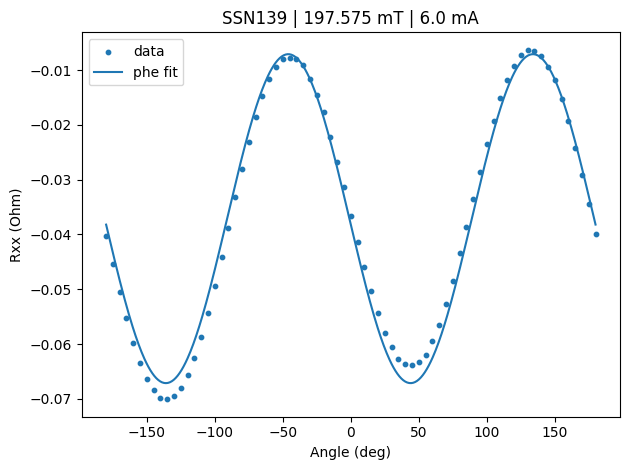

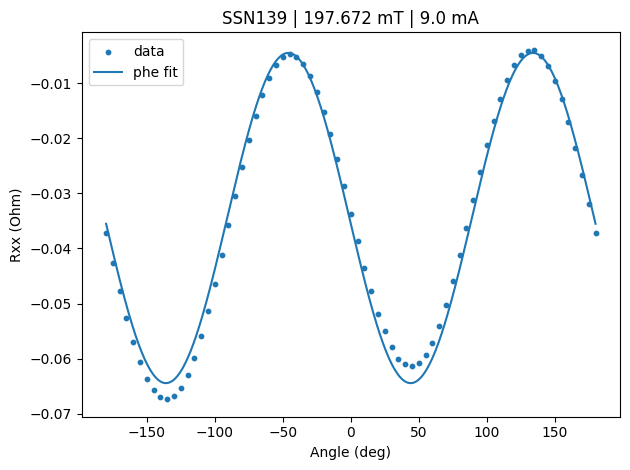

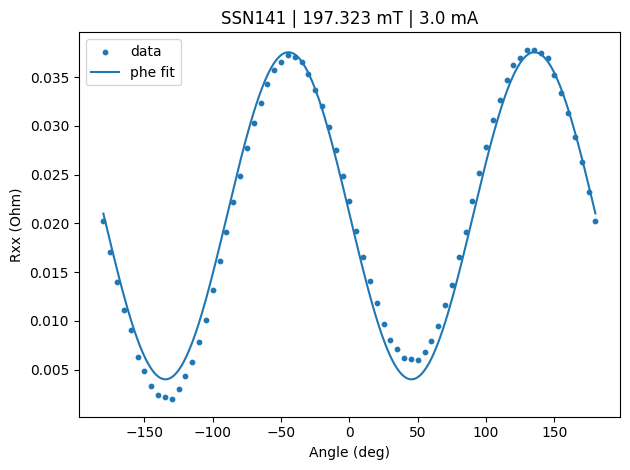

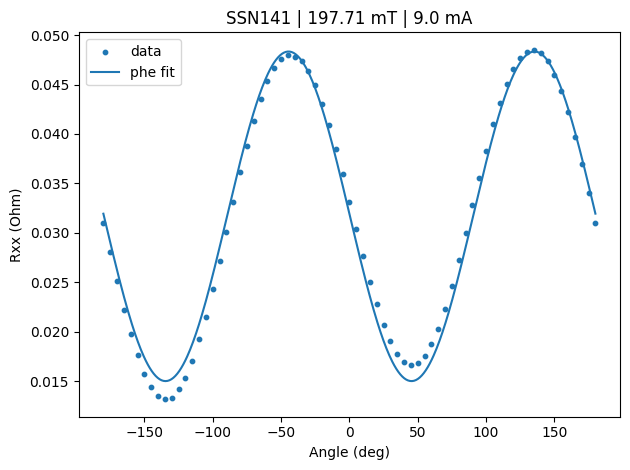

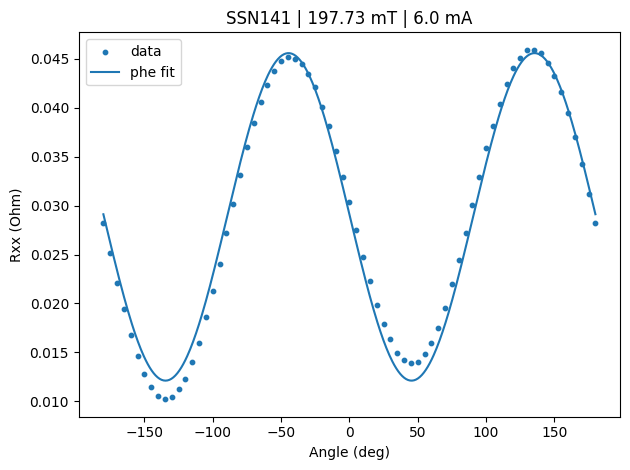

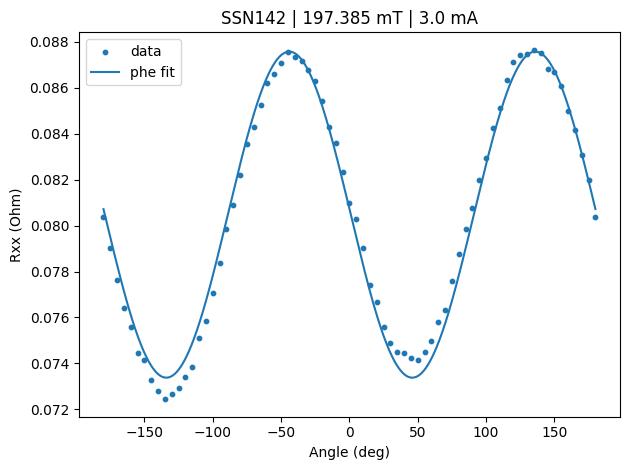

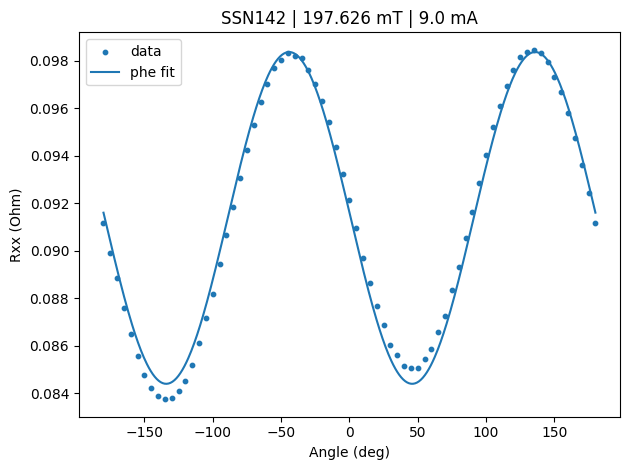

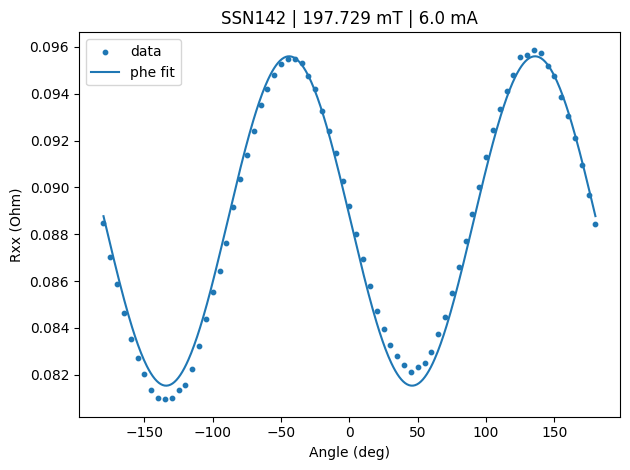

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plot=True

def phe_model(phi, R0, Rphe, phi0):
    return Rphe * np.sin(2 * (phi + phi0)) + R0

# Root directory containing sample folders
root_dir = "."

# Regex to extract field and current from filename
pattern = re.compile(
    r"PHE_field_(?P<field>[0-9.]+)deg_I_in_(?P<current>[0-9.]+)mAtrace(?P<trace>[0-9]+)"
)

all_results = []

for sample in os.listdir(root_dir):

    sample_path = os.path.join(root_dir, sample)

    if not os.path.isdir(sample_path):
        continue

    print(f"\nProcessing sample: {sample}")

    for file in os.listdir(sample_path):

        match = pattern.match(file)
        if not match:
            continue

        field = float(match.group("field"))
        current = float(match.group("current"))
        trace = int(match.group("trace"))

        filepath = os.path.join(sample_path, file)

        try:

            # Read data (skip "R=100")
            df = pd.read_csv(filepath, sep="\t", skiprows=1)
            df.columns = [c.strip() for c in df.columns]

            angle_deg = df["Angle"].values
            phi = np.deg2rad(angle_deg) 
            angle_deg = np.rad2deg(phi)
            Rxx = df["Rxx (ohm)"].values

            # Initial guesses
            guess_R0 = np.mean(Rxx)
            guess_dR = (np.max(Rxx) - np.min(Rxx)) / 2
            guess_phi0 = 0

            # Fit
            popt, pcov = curve_fit(
                phe_model,
                phi,
                Rxx,
                p0=[guess_R0, guess_dR, guess_phi0],
                bounds=([-np.inf, 0, -np.pi/2], [np.inf, np.inf, np.pi])
            )

            R0_fit, dR_fit, phi0_fit = popt

            phe_ratio = dR_fit / R0_fit

            # errors
            perr = np.sqrt(np.diag(pcov))

            R0_err = perr[0]
            dR_err = perr[1]
            phi0_err = perr[2]
            phe_ratio_err = np.sqrt(
                (dR_err / R0_fit)**2 +
                (dR_fit * R0_err / R0_fit**2)**2
            )

            # Store results
            all_results.append({
                "sample": sample,
                "file": file,
                "field_mT": field,
                "current_mA": current,
                "trace": trace,

                "R0_ohm": R0_fit,
                "R0_err": R0_err,

                "deltaR_ohm": dR_fit,
                "deltaR_err": dR_err,

                "phi0_rad": phi0_fit,
                "phi0_rad_err": phi0_err,

                "phi0_deg": np.rad2deg(phi0_fit),
                "phi0_deg_err": np.rad2deg(phi0_err),

                "phe_ratio": phe_ratio,
                "phe_ratio_err": phe_ratio_err
            })

            # Plot data + fit
            phi_fit = np.linspace(min(phi), max(phi), 500)
            if plot:
                plt.figure()
                plt.scatter(angle_deg, Rxx, s=10, label="data")

                plt.plot(
                    np.rad2deg(phi_fit),
                    phe_model(phi_fit, *popt),
                    label="phe fit"
                )

                plt.xlabel("Angle (deg)")
                plt.ylabel("Rxx (Ohm)")
                plt.title(f"{sample} | {field} mT | {current} mA")
                plt.legend()
                plt.tight_layout()

        except Exception as e:
            print(f"Error processing {filepath}: {e}")


# Convert results to DataFrame
results_df = pd.DataFrame(all_results)
# print(results_df["current_mA"], results_df["R0_ohm"], results_df["deltaR_ohm"], results_df["phi0_deg"])

# Save summary file
results_df.to_csv("PHE_fit_summary.csv", index=False)
print(results_df)
print("\nAnalysis finished. Results saved to phe_fit_summary.csv")

In [7]:

def weighted_mean_with_scatter(values, errors):

    values = np.array(values)
    errors = np.array(errors)

    weights = 1 / errors**2

    weighted_mean = np.sum(weights * values) / np.sum(weights)

    weighted_err = np.sqrt(1 / np.sum(weights))

    scatter = np.std(values, ddof=1)

    total_err = np.sqrt(weighted_err**2 + scatter**2)

    return weighted_mean, total_err, scatter


summary_rows = []

for sample in results_df["sample"].unique():

    df_sample = results_df[results_df["sample"] == sample]

    # R0
    R0_mean, R0_err, R0_scatter = weighted_mean_with_scatter(
        df_sample["R0_ohm"],
        df_sample["R0_err"]
    )

    # dR
    dR_mean, dR_err, dR_scatter = weighted_mean_with_scatter(
        df_sample["deltaR_ohm"],
        df_sample["deltaR_err"]
    )

    summary_rows.append({
        "sample": sample,

        "R0_mean": R0_mean,
        "R0_err": R0_err,
        "R0_scatter": R0_scatter,

        "dR_mean": dR_mean,
        "dR_err": dR_err,
        "dR_scatter": dR_scatter
    })

summary_df = pd.DataFrame(summary_rows)

summary_df.to_csv("phe_sample_summary.csv", index=False)

print(summary_df)

   sample   R0_mean    R0_err  R0_scatter   dR_mean    dR_err  dR_scatter
0  SSN092  0.054878  0.005589    0.005589  0.005291  0.000067    0.000050
1  SSN093 -0.024552  0.005322    0.005322  0.005289  0.000057    0.000038
2  SSN094  0.040239  0.005513    0.005513  0.005258  0.000045    0.000028
3  SSN139 -0.038359  0.005478    0.005476  0.030001  0.000226    0.000049
4  SSN141  0.027499  0.005657    0.005656  0.016717  0.000139    0.000059
5  SSN142  0.087322  0.005659    0.005659  0.007033  0.000073    0.000054


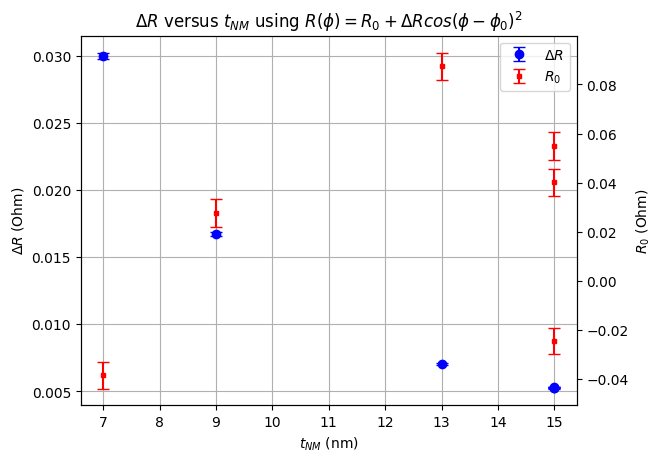

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

thickness_map = {
    "SSN092": {"t_FM": 2e-9,"t_NM": 15e-9,"label": "pt15"},
    "SSN093": {"t_FM": 2.5e-9,"t_NM": 15e-9,"label": "pt15"},
    "SSN094": {"t_FM": 3e-9,"t_NM": 15e-9,"label": "pt15"},

    "SSN138": {"t_FM": 4e-9,"t_NM": 3e-9,"label": "CFB4"},
    "SSN101": {"t_FM": 4e-9,"t_NM": 5e-9,"label": "CFB4"},
    "SSN139": {"t_FM": 4e-9,"t_NM": 7e-9,"label": "CFB4"},
    "SSN140": {"t_FM": 4e-9,"t_NM": 18e-9,"label": "CFB4"},
    "SSN141": {"t_FM": 4e-9,"t_NM": 9e-9,"label": "CFB4"},
    "SSN142": {"t_FM": 4e-9,"t_NM": 13e-9,"label": "CFB4"},
    "SSN095": {"t_FM": 4e-9,"t_NM": 15e-9,"label": "CFB4"},
    "SSN143": {"t_FM": 4e-9,"t_NM": 13e-9,"label": "CFB4"},
}
# assuming your dataframe is called df
summary_df["t_NM"] = summary_df["sample"].map(lambda x: thickness_map[x]["t_NM"])
summary_df["t_NM_nm"] = summary_df["t_NM"] * 1e9
summary_df = summary_df.sort_values("t_NM_nm")


import matplotlib.pyplot as plt

# sort for nicer plotting
summary_df = summary_df.sort_values("t_NM_nm")

fig, ax1 = plt.subplots()

# --- Left axis: dR ---
ax1.errorbar(
    summary_df["t_NM_nm"],
    summary_df["dR_mean"],
    yerr=summary_df["dR_err"],
    fmt='o',
    capsize=4,
    label="$\\Delta R$",
    color='blue'
)
ax1.set_xlabel("$t_{NM}$ (nm)")
ax1.set_ylabel("$\\Delta R$ (Ohm)")
ax1.grid(True)

# --- Right axis: R0 ---
ax2 = ax1.twinx()

ax2.errorbar(
    summary_df["t_NM_nm"],
    summary_df["R0_mean"],
    yerr=summary_df["R0_err"],
    fmt='s',
    capsize=4,
    # linestyle='--',
    label="$R_0$",
    color='red',
    markersize=3
)
ax2.set_ylabel("$R_0$ (Ohm)")

# --- Optional: combine legends ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

# plt.xlabel("$t_{NM}$ (nm)")
# plt.ylabel("$\\Delta R$")
plt.title("$\\Delta R$ versus $t_{NM}$ using $R(\\phi) = R_0 + \\Delta R cos(\\phi - \\phi_0)^2$")

# plt.grid(True)
plt.show()



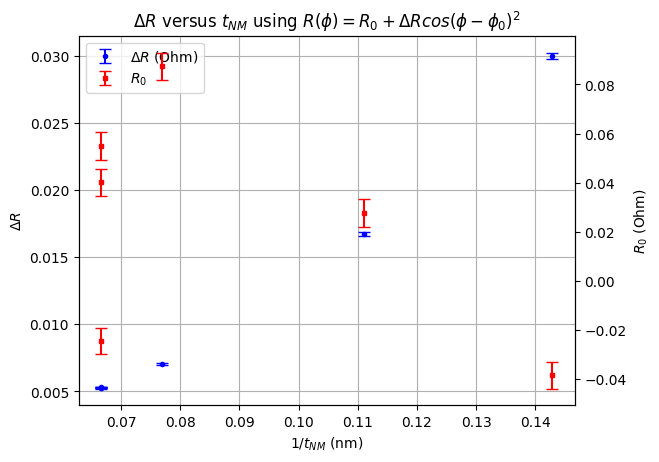

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

thickness_map = {
    "SSN092": {"t_FM": 2e-9,"t_NM": 15e-9,"label": "pt15"},
    "SSN093": {"t_FM": 2.5e-9,"t_NM": 15e-9,"label": "pt15"},
    "SSN094": {"t_FM": 3e-9,"t_NM": 15e-9,"label": "pt15"},

    "SSN138": {"t_FM": 4e-9,"t_NM": 3e-9,"label": "CFB4"},
    "SSN101": {"t_FM": 4e-9,"t_NM": 5e-9,"label": "CFB4"},
    "SSN139": {"t_FM": 4e-9,"t_NM": 7e-9,"label": "CFB4"},
    "SSN140": {"t_FM": 4e-9,"t_NM": 18e-9,"label": "CFB4"},
    "SSN141": {"t_FM": 4e-9,"t_NM": 9e-9,"label": "CFB4"},
    "SSN142": {"t_FM": 4e-9,"t_NM": 13e-9,"label": "CFB4"},
    "SSN095": {"t_FM": 4e-9,"t_NM": 15e-9,"label": "CFB4"},
    "SSN143": {"t_FM": 4e-9,"t_NM": 13e-9,"label": "CFB4"},
}
# assuming your dataframe is called df
summary_df["t_NM"] = summary_df["sample"].map(lambda x: thickness_map[x]["t_NM"])
summary_df["t_NM_nm"] = summary_df["t_NM"] * 1e9
summary_df = summary_df.sort_values("t_NM_nm")


import matplotlib.pyplot as plt

# sort for nicer plotting
summary_df = summary_df.sort_values("t_NM_nm")

fig, ax1 = plt.subplots()

# --- Left axis: dR ---
ax1.errorbar(
    1/summary_df["t_NM_nm"],
    summary_df["dR_mean"],
    yerr=summary_df["dR_err"],
    fmt='o',
    capsize=4,
    label="$\\Delta R$ (Ohm)",
    color='blue',
    markersize=3

)
ax1.set_xlabel("1/$t_{NM}$ (nm)")
ax1.set_ylabel("$\\Delta R$")
ax1.grid(True)

# --- Right axis: R0 ---
ax2 = ax1.twinx()

ax2.errorbar(
    1/summary_df["t_NM_nm"],
    summary_df["R0_mean"],
    yerr=summary_df["R0_err"],
    fmt='s',
    capsize=4,
    # linestyle='--',
    label="$R_0$",
    color='red',
    markersize=3
)
ax2.set_ylabel("$R_0$ (Ohm)")

# --- Optional: combine legends ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

# plt.xlabel("$t_{NM}$ (nm)")
# plt.ylabel("$\\Delta R$")
plt.title("$\\Delta R$ versus $t_{NM}$ using $R(\\phi) = R_0 + \\Delta R cos(\\phi - \\phi_0)^2$")

# plt.grid(True)
plt.show()



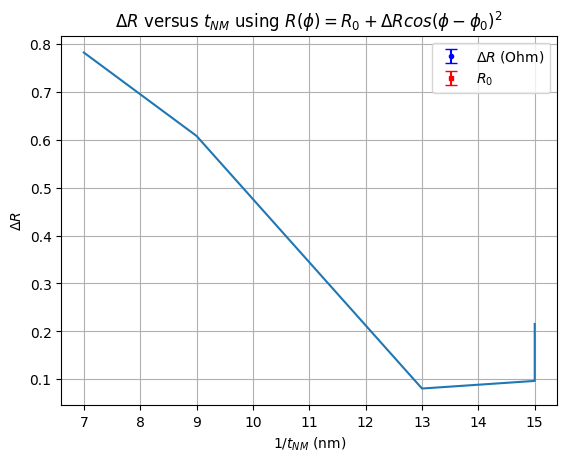

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

thickness_map = {
    "SSN092": {"t_FM": 2e-9,"t_NM": 15e-9,"label": "pt15"},
    "SSN093": {"t_FM": 2.5e-9,"t_NM": 15e-9,"label": "pt15"},
    "SSN094": {"t_FM": 3e-9,"t_NM": 15e-9,"label": "pt15"},

    "SSN138": {"t_FM": 4e-9,"t_NM": 3e-9,"label": "CFB4"},
    "SSN101": {"t_FM": 4e-9,"t_NM": 5e-9,"label": "CFB4"},
    "SSN139": {"t_FM": 4e-9,"t_NM": 7e-9,"label": "CFB4"},
    "SSN140": {"t_FM": 4e-9,"t_NM": 18e-9,"label": "CFB4"},
    "SSN141": {"t_FM": 4e-9,"t_NM": 9e-9,"label": "CFB4"},
    "SSN142": {"t_FM": 4e-9,"t_NM": 13e-9,"label": "CFB4"},
    "SSN095": {"t_FM": 4e-9,"t_NM": 15e-9,"label": "CFB4"},
    "SSN143": {"t_FM": 4e-9,"t_NM": 13e-9,"label": "CFB4"},
}
# assuming your dataframe is called df
summary_df["t_NM"] = summary_df["sample"].map(lambda x: thickness_map[x]["t_NM"])
summary_df["t_NM_nm"] = summary_df["t_NM"] * 1e9
summary_df = summary_df.sort_values("t_NM_nm")


import matplotlib.pyplot as plt

# sort for nicer plotting
summary_df = summary_df.sort_values("t_NM_nm")

fig, ax1 = plt.subplots()

# --- Left axis: dR ---
ax1.plot(
    summary_df["t_NM_nm"],
    summary_df["dR_mean"]/abs(summary_df["R0_mean"]),
    # yerr=summary_df["dR_err"],
    # fmt='o',
    # capsize=4,
    # label="$\\Delta R$ (Ohm)",
    # color='blue',

)
ax1.set_xlabel("1/$t_{NM}$ (nm)")
ax1.set_ylabel("$\\Delta R$")
ax1.grid(True)

# --- Right axis: R0 ---
# ax2 = ax1.twinx()

# ax2.errorbar(
#     1/summary_df["t_NM_nm"],
#     summary_df["R0_mean"],
#     yerr=summary_df["R0_err"],
#     fmt='s',
#     capsize=4,
#     # linestyle='--',
#     label="$R_0$",
#     color='red',
#     markersize=3
# )
# ax2.set_ylabel("$R_0$ (Ohm)")

# # --- Optional: combine legends ---
# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

# plt.xlabel("$t_{NM}$ (nm)")
# plt.ylabel("$\\Delta R$")
plt.title("$\\Delta R$ versus $t_{NM}$ using $R(\\phi) = R_0 + \\Delta R cos(\\phi - \\phi_0)^2$")

# plt.grid(True)
plt.show()

